In [ ]:
#import of used libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import datetime #easier to process datetime format as a variable
import plotly.express as px
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor,DMatrix
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import itertools
from statsmodels.tsa.arima.model import ARIMA

# Predicting EUR/USD 


### Descriptive analysis of your data

First, we chose a dataset from Kaggle. This dataset consists of data collected every four hours from the EUR/USD exchange rate. It contains the date, opening price, closing price, highest price, lowest price, and volume. 

In [154]:
# download csv file locally

data = pd.read_csv("Data_EURUSD_4h.csv")
data.info()
data.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28860 entries, 0 to 28859
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Gmt time  28860 non-null  object 
 1   open      28860 non-null  float64
 2   high      28860 non-null  float64
 3   low       28860 non-null  float64
 4   close     28860 non-null  float64
 5   volume    28860 non-null  float64
dtypes: float64(5), object(1)
memory usage: 1.3+ MB


(28860, 6)

In [155]:
data.head()

,Gmt time,open,high,low,close,volume
0,04.05.2003 21:00:00.000,1.12354,1.12354,1.12166,1.12274,95533.0976
1,05.05.2003 01:00:00.000,1.12242,1.12276,1.12067,1.12126,93778.5996
2,05.05.2003 05:00:00.000,1.12139,1.12255,1.12030,1.12113,90924.6992
3,05.05.2003 09:00:00.000,1.12092,1.12331,1.12049,1.12174,91254.6992
4,05.05.2003 13:00:00.000,1.12194,1.12900,1.12130,1.12712,308003.4083


In [156]:
# show if there is any missing value
data.isnull().sum()

Gmt time    0
open        0
high        0
low         0
close       0
volume      0
dtype: int64

In [157]:
# show if a value is zero
(data == 0).sum()

Gmt time     0
open         0
high         0
low          0
close        0
volume      34
dtype: int64

In [158]:
data[data['volume'] == 0]

,Gmt time,open,high,low,close,volume
120,31.05.2003 21:00:00.000,1.17691,1.17825,1.17691,1.17825,0.0
1561,30.04.2004 21:00:00.000,1.19800,1.19853,1.19800,1.19853,0.0
1952,31.07.2004 21:00:00.000,1.20195,1.20195,1.20161,1.20161,0.0
3123,30.04.2005 21:00:00.000,1.28715,1.28722,1.28715,1.28722,0.0
3784,30.09.2005 21:00:00.000,1.20266,1.20664,1.20266,1.20664,0.0
4175,31.12.2005 22:00:00.000,1.18465,1.18470,1.18465,1.18470,0.0
4566,31.03.2006 22:00:00.000,1.21158,1.21158,1.21144,1.21144,0.0
4957,30.06.2006 21:00:00.000,1.27925,1.27925,1.27865,1.27865,0.0
5348,30.09.2006 21:00:00.000,1.26735,1.26735,1.26704,1.26704,0.0
6129,31.03.2007 21:00:00.000,1.33560,1.33560,1.33545,1.33545,0.0


In [159]:
# drop column Gmt time
data['Gmt time'] = pd.to_datetime(data['Gmt time'],format = "%d.%m.%Y %H:%M:%S.%f")

In [160]:
mean_volume = data['volume'].mean()

print("Mean volume (excluding zeros):", mean_volume)

Mean volume (excluding zeros): 83078.83538814969


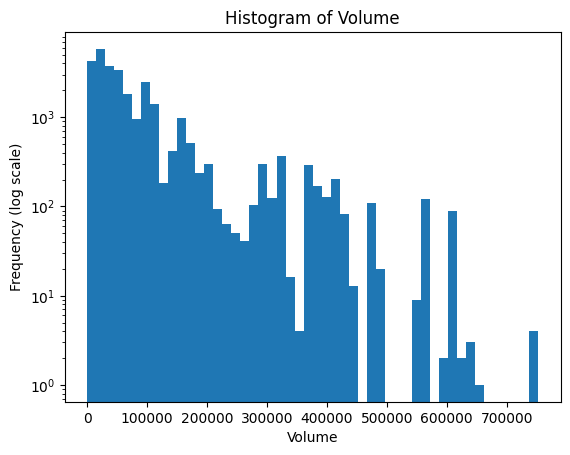

In [161]:
# histogram of volume
import matplotlib.pyplot as plt
plt.hist(data['volume'], bins=50)
plt.yscale('log')
plt.xlabel('Volume')
plt.ylabel('Frequency (log scale)')
plt.title('Histogram of Volume')
plt.show()

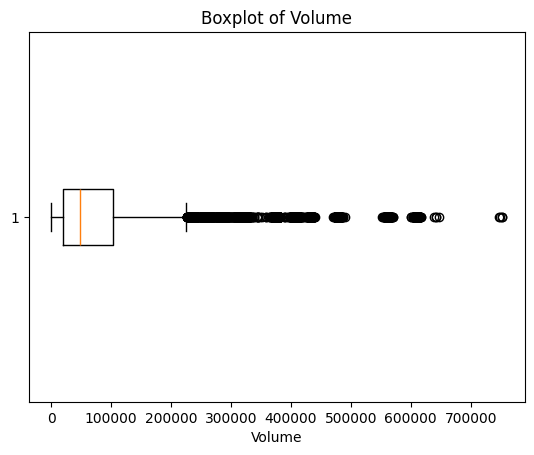

In [162]:
# boxplot of volume
plt.boxplot(data['volume'], vert=False)
plt.xlabel('Volume')
plt.title('Boxplot of Volume')
plt.show()


with the different plot, we can concluded that 0 is not an aberrant value. 

In [163]:
data.describe()

,Gmt time,open,high,low,close,volume
count,28860,28860.000000,28860.000000,28860.000000,28860.000000,28860.000000
mean,2012-07-20 04:48:47.525987584,1.254449,1.256497,1.252384,1.254457,83078.835388
min,2003-05-04 21:00:00,1.036930,1.039200,1.034050,1.036970,0.000000
25%,2007-12-10 09:00:00,1.154278,1.155988,1.152438,1.154285,20322.189925
50%,2012-07-16 11:00:00,1.242230,1.244390,1.239885,1.242260,47812.714850
75%,2017-02-28 11:00:00,1.338760,1.340750,1.336512,1.338763,102454.949700
max,2021-10-15 17:00:00,1.599500,1.604030,1.596950,1.599240,752269.093800
std,NaN,0.119505,0.119839,0.119131,0.119503,100637.239637


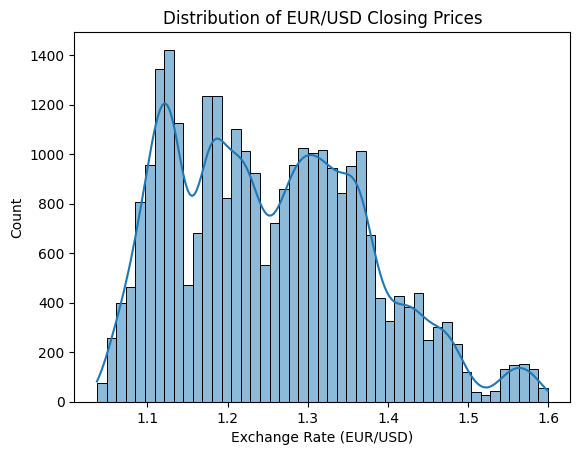

In [164]:
# Histogram of the distrubution of Euro and Dollar exchange rates

sns.histplot(data['close'], kde=True)
plt.title("Distribution of EUR/USD Closing Prices")
plt.xlabel("Exchange Rate (EUR/USD)")
plt.show()

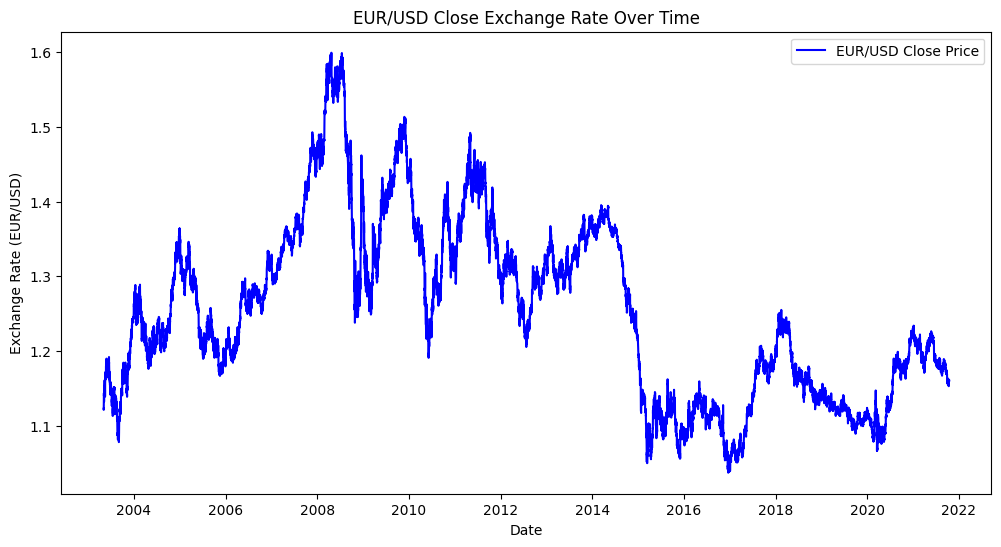

In [165]:
# Plot of close price over time 
plt.figure(figsize=(12,6))
plt.plot(data['Gmt time'], data['close'], label='EUR/USD Close Price', color='blue')
plt.title('EUR/USD Close Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EUR/USD)')
plt.legend()
plt.show()

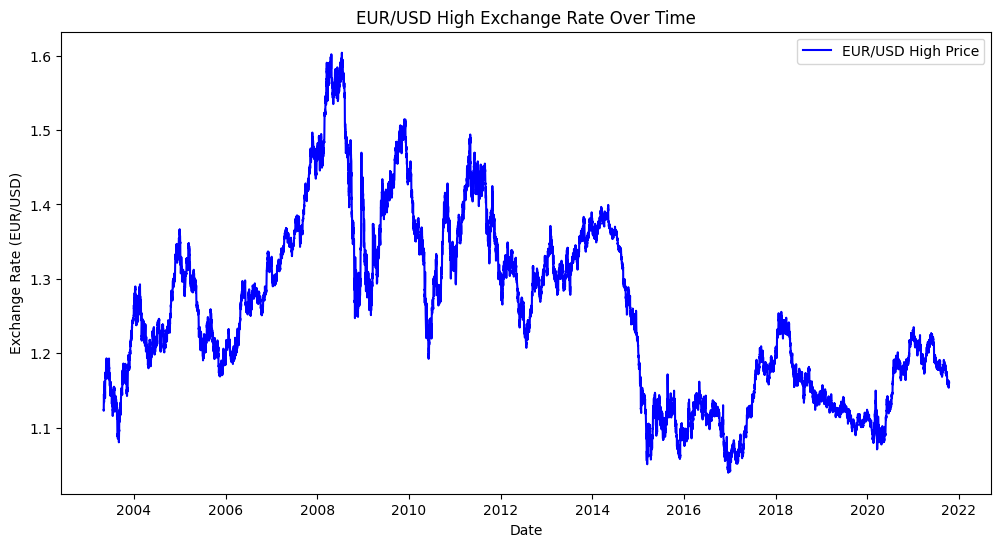

In [166]:
# Plot of highest price every 4H over time
plt.figure(figsize=(12,6))
plt.plot(data["Gmt time"], data['high'], label='EUR/USD High Price', color='blue')
plt.title('EUR/USD High Exchange Rate Over Time')
plt.xlabel("Date")
plt.ylabel('Exchange Rate (EUR/USD)')
plt.legend()
plt.show()

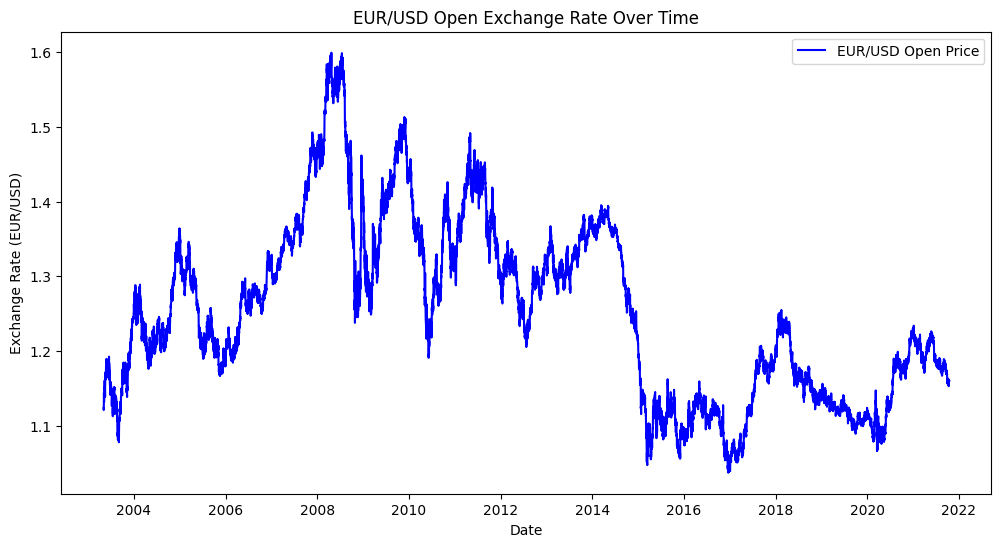

In [167]:
# Plot of open price overtime
plt.figure(figsize=(12,6))
plt.plot(data["Gmt time"], data['open'], label='EUR/USD Open Price', color='blue')
plt.title('EUR/USD Open Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EUR/USD)')
plt.legend()
plt.show()

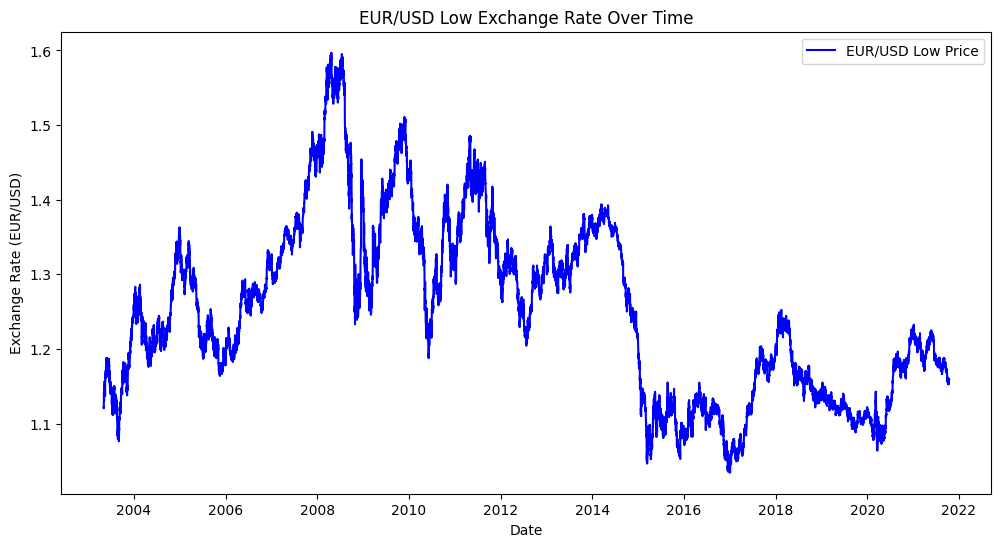

In [168]:
# Plot of Lowest price every 4H over time
plt.figure(figsize=(12,6))
plt.plot(data["Gmt time"], data['low'], label='EUR/USD Low Price', color='blue')
plt.title('EUR/USD Low Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EUR/USD)')
plt.legend()
plt.show()

### Conclusion : Descriptive analysis of your data.
Our dataset contains historical exchange rates between Euro and US Dollar.
this dataset contains 28860 records with 6 features: Gmt time, Open, High, Low, Close, and Volume.
Remainder that the FX euro dollar is open 24 hours a day from Monday to Friday, so the data is recorded for every trading day. And without holidays.
we have seen that there are no missing values and the zero values are not problematic.

The plots show that there are no abberant values in the data. The trend is mostly continous and can be used for moving average forecast and pattern recognition.




### Implementation of basic linear regression models and treeclassifier

In this part we'll be trying to forecast the evolution of close price with basic models. Since time isn't really a usable feature we'll be introducing some pattern features like moving average and volatility that are used in Time Series Econometrics for this specific kind of time series to. The patterns are meant to help the model detect trends and forecast at an H+4 timeframe, we'll be specifically cautious to avoid data leakage when computing moving average.

In [169]:
df = data.drop('Gmt time',axis = 1).copy()


# add some indicators that we know without volume data
df['Return'] = df['close'].pct_change()
df['MA5'] = df['close'].rolling(5).mean()
df['MA20'] = df['close'].rolling(20).mean()
df['Volatility'] = df['Return'].rolling(10).std()
df['RSI'] = 100 - (100 / (1 + df['Return'].rolling(14).apply(lambda x: (x[x > 0].sum() / -x[x < 0].sum()) if -x[x < 0].sum() != 0 else 0)))
df["EMA12"] = df['close'].ewm(span=12, adjust=False).mean()
df["EMA26"] = df['close'].ewm(span=26, adjust=False).mean()
df["MACD"] = df["EMA12"] - df["EMA26"]
df["VMA5"] = df['volume'].rolling(5).mean()
df["VMA20"] = df['volume'].rolling(20).mean()
df["Volume_Ratio"] = df["VMA5"] / df["VMA20"]

# Add lagged values to keep memory of the past
for lag in range(1, 6):  # 5 days of lag
    df[f'Lag_{lag}'] = df['close'].shift(lag)
    
# Delete missing values
df = df.dropna()

print("\nIndicator created :")
print(df.head())

# We choose to predict the market direction (1 = up, 0 = down)
df['Target'] = (df['Return'].shift(-1) > 0).astype(int)
df = df.dropna()

X = df.drop(columns=['Target', 'Return', 'open', 'high', 'low']) 
y = df['Target']

# split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Different classification models to test

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', C=1.0, probability=True)
}

results = {}

print("\nModel evaluation :")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = [acc, prec, rec, f1, auc]
    print(f"{name:20s} , Acc: {acc:.3f} , Prec: {prec:.3f} , Rec: {rec:.3f} , F1: {f1:.3f} , AUC: {auc:.3f}")

# Results 
results_df = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1", "AUC"]).T
print("\nResume of performance :")
print(results_df)

# best model
best_model_name = results_df["AUC"].idxmax()
print(f"\nBest model based on AUC: {best_model_name}")


Indicator created :
       open     high      low    close       volume    Return       MA5  \
19  1.13529  1.13623  1.13169  1.13210   98309.7012 -0.003495  1.136078   
20  1.13155  1.13412  1.13026  1.13312   89533.6016  0.000901  1.134374   
21  1.13341  1.14342  1.13236  1.14334   91527.1992  0.009019  1.136280   
22  1.14336  1.14855  1.14240  1.14540  313726.1035  0.001802  1.138006   
23  1.14547  1.15092  1.14514  1.15026  373156.8946  0.004243  1.140844   

        MA20  Volatility        RSI  ...     EMA26      MACD          VMA5  \
19  1.132595    0.003787  55.531832  ...  1.132100  0.003283  193500.21878   
20  1.133114    0.003797  55.444104  ...  1.132176  0.002860  193497.19886   
21  1.134218    0.004149  65.787992  ...  1.133003  0.003310  149653.09962   
22  1.135431    0.004176  63.263365  ...  1.133921  0.003790  137150.36094   
23  1.136858    0.004341  66.371954  ...  1.135131  0.004510  193250.70002   

            VMA20  Volume_Ratio    Lag_1    Lag_2    Lag_3 

We notice that basic models aren't suited for time series we'll need implement more complex models later like ARIMA, XGBoost that are better at forecasting time series and are known to be reliable on classic ForEx trading pairs.

### Xgboost Pipeline

 
 - import 
 - visualisation
 - scaling 
 - xgboost setup
 - hyperparametter fitting



In [170]:
#import dataframe and convert datetime

df= pd.read_csv("Data_EURUSD_4h.csv")
df['Gmt time'] = pd.to_datetime(df['Gmt time'],format = "%d.%m.%Y %H:%M:%S.%f")
df.head()

,Gmt time,open,high,low,close,volume
0,2003-05-04 21:00:00,1.12354,1.12354,1.12166,1.12274,95533.0976
1,2003-05-05 01:00:00,1.12242,1.12276,1.12067,1.12126,93778.5996
2,2003-05-05 05:00:00,1.12139,1.12255,1.12030,1.12113,90924.6992
3,2003-05-05 09:00:00,1.12092,1.12331,1.12049,1.12174,91254.6992
4,2003-05-05 13:00:00,1.12194,1.12900,1.12130,1.12712,308003.4083


In [171]:
fig = px.line(df,
              x = "Gmt time",
              y = "close",
              title = "Close price over time", 
)

fig.update_traces(line_color="darkred")
fig.show()


In [172]:
# data augmentation for pattern features and recognitions

df_upgrade = pd.DataFrame()
df_upgrade["Time"] = df["Gmt time"]
df_upgrade["close"] = df["close"]
df_upgrade["volume"] = df["volume"]

#adding moving average
df_upgrade["MA_5"] = df_upgrade["close"].shift(1).rolling(5).mean()
df_upgrade["MA_50"] = df_upgrade["close"].shift(1).rolling(50).mean()
df_upgrade["MA_250"] = df_upgrade["close"].shift(1).rolling(250).mean()

#adding std that serves as volatility 
df_upgrade["std_5"] = df_upgrade["close"].shift(1).rolling(5).std()
df_upgrade["std_50"] = df_upgrade["close"].shift(1).rolling(50).std()
df_upgrade["std_250"] = df_upgrade["close"].shift(1).rolling(250).std()

#adding returns
df_upgrade["returns_1"] = ((df_upgrade["close"]-df_upgrade["close"].shift(1))/df_upgrade['close'].shift(1))
df_upgrade["returns_5"] = ((df_upgrade["close"]-df_upgrade["close"].shift(5))/df_upgrade['close'].shift(5))
df_upgrade["returns_50"] = ((df_upgrade["close"]-df_upgrade["close"].shift(50))/df_upgrade['close'].shift(50))
df_upgrade["returns_250"] = ((df_upgrade["close"]-df_upgrade["close"].shift(250))/df_upgrade['close'].shift(250))

#adding volatility
df_upgrade["volatility_5"]  = df_upgrade["returns_1"].shift(1).rolling(5).std()
df_upgrade["volatility_50"]  = df_upgrade["returns_1"].shift(1).rolling(50).std()
df_upgrade["volatility_250"] = df_upgrade["returns_1"].shift(1).rolling(250).std()


df_upgrade = df_upgrade.dropna(axis = 0).reset_index(drop = True)

df_upgrade.head(5)


,Time,close,volume,MA_5,MA_50,MA_250,std_5,std_50,std_250,returns_1,returns_5,returns_50,returns_250,volatility_5,volatility_50,volatility_250
0,2003-07-01 13:00:00,1.15772,305286.4981,1.152526,1.153544,1.163531,0.001516,0.008579,0.015871,0.002737,0.005699,-0.003563,0.032517,0.000885,0.002464,0.002840
1,2003-07-01 17:00:00,1.15608,373451.0000,1.153838,1.153461,1.163677,0.002535,0.008517,0.015647,-0.001417,0.003672,-0.008491,0.031174,0.001250,0.002496,0.002844
2,2003-07-01 21:00:00,1.15545,92759.5000,1.154684,1.153263,1.163817,0.002408,0.008333,0.015420,-0.000545,0.003552,-0.010787,0.030052,0.001708,0.002448,0.002845
3,2003-07-02 01:00:00,1.15498,92156.1992,1.155502,1.153011,1.163952,0.001532,0.008063,0.015196,-0.000407,0.001109,-0.014547,0.024718,0.001729,0.002432,0.002845
4,2003-07-02 05:00:00,1.15338,90669.9004,1.155758,1.152670,1.164063,0.001234,0.007589,0.015026,-0.001385,-0.001022,-0.014845,0.022464,0.001602,0.002375,0.002830


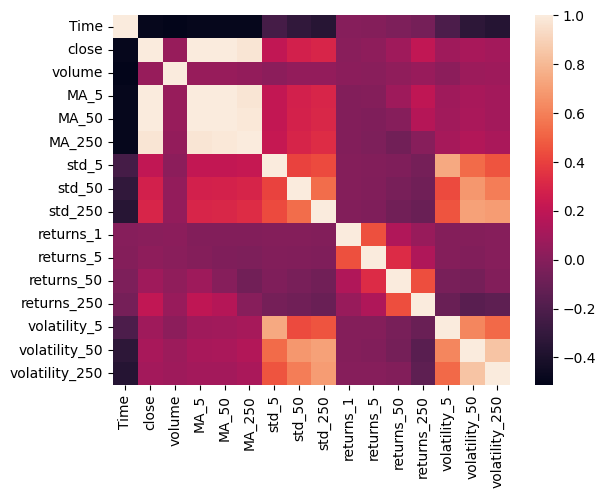

In [173]:
#Evaluate the correlation between the features 
sns.heatmap(df_upgrade.corr())
plt.show()

We can notice that the close price is mostly correlated with moving average as expected from a pretty stable exchange pair. We also notice that its slightly correlated to the returns and volatility.

In [174]:
#Split time periods for training 

rows = len(df_upgrade)
split_index = int(rows*0.8)

df_train = df_upgrade.iloc[:split_index]
df_validation = df_upgrade.iloc[split_index:]

X_train = df_train.drop(['close','Time'],axis = 'columns')
y_train = df_train['close']

X_test = df_validation.drop(['close','Time'],axis = 'columns')
y_test = df_validation['close']


In [175]:
#scaling

scaler = StandardScaler()

scaler.fit(X_train)

X_scaled_train = scaler.transform(X_train)
X_scaled_test = scaler.transform(X_test)

In [176]:
#XGBRegressor hyperparameters fitting

xgb = XGBRegressor(random_state = 0)

#most efficient data structure for the xgboost regressor
data = DMatrix(data = X_train, label = y_train)

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2], 
    'n_estimators': [100, 250, 500],

    'max_depth': [3, 5, 7],  
    'min_child_weight': [1, 3, 5], 
    
    'subsample': [0.5, 0.7, 1.0], 
    'colsample_bytree': [0.5, 0.7, 1.0], 
}

grid_search = GridSearchCV(estimator = xgb,
                           param_grid = param_grid,
                           scoring = "neg_mean_squared_error",
                           cv =4,
                           verbose = 1,
                           n_jobs = -1)

grid_search.fit(X_train,y_train)

print("Best parameters for XGBRegressor:", grid_search.best_params_)
print("Best MSE for XGBRegressor:", -grid_search.best_score_)


Fitting 4 folds for each of 729 candidates, totalling 2916 fits
Best parameters for XGBRegressor: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 1.0}
Best MSE for XGBRegressor: 0.0002950459707631498


In [177]:
xgb_best = grid_search.best_estimator_

xgb_best.fit(X_train,y_train)

y_pred = xgb_best.predict(X_test)

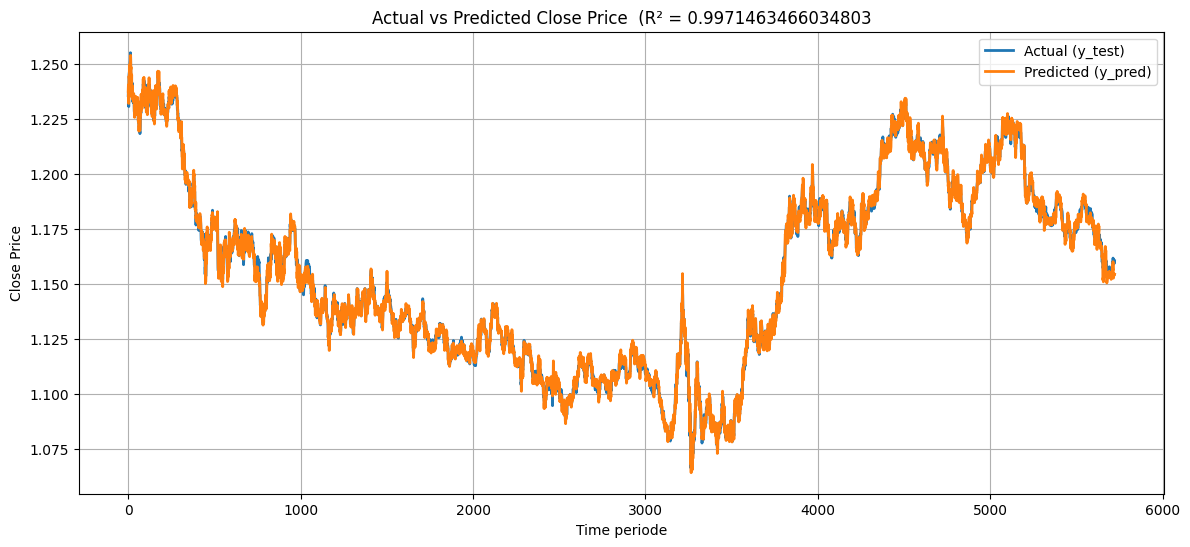

In [178]:
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual (y_test)", linewidth=2)
plt.plot(y_pred, label="Predicted (y_pred)", linewidth=2)

plt.title("Actual vs Predicted Close Price  (R² = {}".format(r2))
plt.xlabel("Time periode")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)



We noticed afterward that there may be some data leakage 


In [179]:
#shift the target by one time period to predict indeed H+4 instead of allowing the model to just reverse engineer the close price from the leaking moving average


df_upgrade["target"] = df_upgrade["close"].shift(-1)
df_upgrade = df_upgrade.dropna().reset_index(drop=True)

X = df_upgrade.drop(["Time", "close", "target"], axis=1)
y = df_upgrade["target"]

rows = len(df_upgrade)
split_index = int(rows * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test  = X.iloc[split_index:]
y_test  = y.iloc[split_index:]



In [180]:
scaler = StandardScaler()

scaler.fit(X_train)

X_scaled_train = scaler.transform(X_train)
X_scaled_test = scaler.transform(X_test)

In [181]:
xgb = XGBRegressor(random_state = 0)

#most efficient data structure for the xgboost regressor
data = DMatrix(data = X_train, label = y_train)

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2], 
    'n_estimators': [100, 250, 500],

    'max_depth': [3, 5, 7],  
    'min_child_weight': [1, 3, 5], 
    
    'subsample': [0.5, 0.7, 1.0], 
    'colsample_bytree': [0.5, 0.7, 1.0], 
}
grid_search = GridSearchCV(estimator = xgb,
                           param_grid = param_grid,
                           scoring = "neg_mean_squared_error",
                           cv =4,
                           verbose = 1,
                           n_jobs = -1)

grid_search.fit(X_train,y_train)

print("Best parameters for XGBRegressor:", grid_search.best_params_)
print("Best MSE for XGBRegressor:", -grid_search.best_score_)


Fitting 4 folds for each of 729 candidates, totalling 2916 fits
Best parameters for XGBRegressor: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 1.0}
Best MSE for XGBRegressor: 0.00032864515638923806


In [182]:
xgb_best = grid_search.best_estimator_

xgb_best.fit(X_train,y_train)

y_pred = xgb_best.predict(X_test)

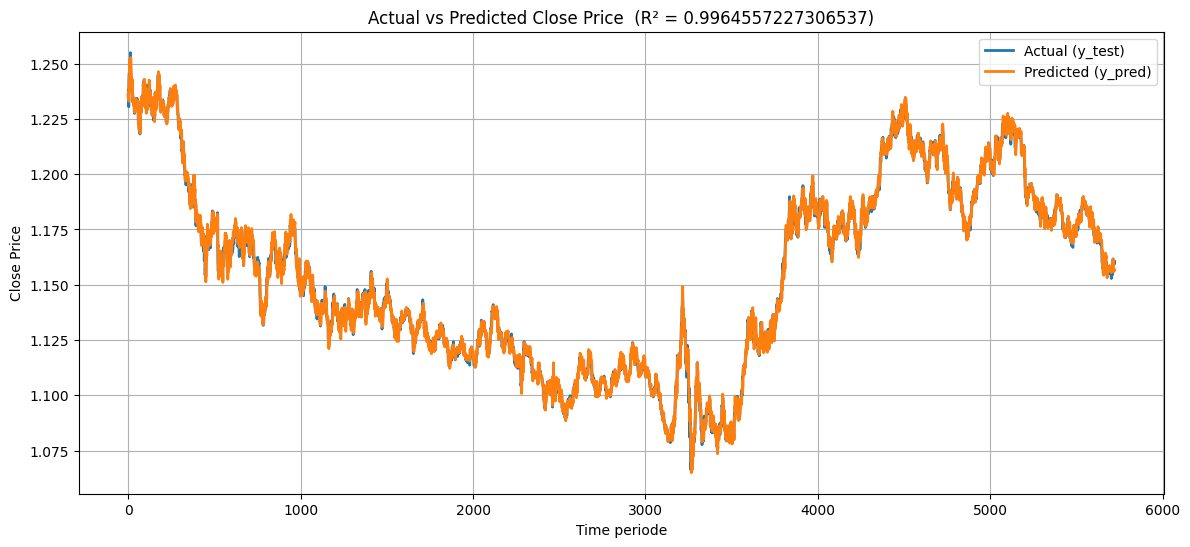

In [183]:
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual (y_test)", linewidth=2)
plt.plot(y_pred, label="Predicted (y_pred)", linewidth=2)

plt.title("Actual vs Predicted Close Price  (R² = {})".format(r2))
plt.xlabel("Time periode")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)


Removing the data leakage slightly reduced de R2 score but since we gave enough features the model is still able to perform correctly for this exchange rate since it's pretty stable.



### ARIMA

In [187]:
# load data
df = pd.read_csv("Data_EURUSD_4h.csv")
df['Gmt time'] = pd.to_datetime(df['Gmt time'], format="%d.%m.%Y %H:%M:%S.%f")
df = df.sort_values("Gmt time").reset_index(drop=True)
ts = df["close"]

In [188]:
# check stationarity (ADF test)
result = adfuller(ts)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.2048563178118483
p-value: 0.20448761753489503


In [189]:
# Fit ARIMA manualy
warnings.filterwarnings("ignore")
model = ARIMA(ts, order=(5,1,5))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                28860
Model:                 ARIMA(5, 1, 5)   Log Likelihood              126740.996
Date:                Sat, 29 Nov 2025   AIC                        -253459.992
Time:                        10:35:27   BIC                        -253369.020
Sample:                             0   HQIC                       -253430.749
                              - 28860                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3995      0.262      5.334      0.000       0.885       1.914
ar.L2         -0.5931      0.268     -2.213      0.027      -1.118      -0.068
ar.L3         -0.3822      0.225     -1.701      0.0

In [190]:
# Forecast next values
n_steps = 200 
forecast = model_fit.forecast(steps=n_steps)

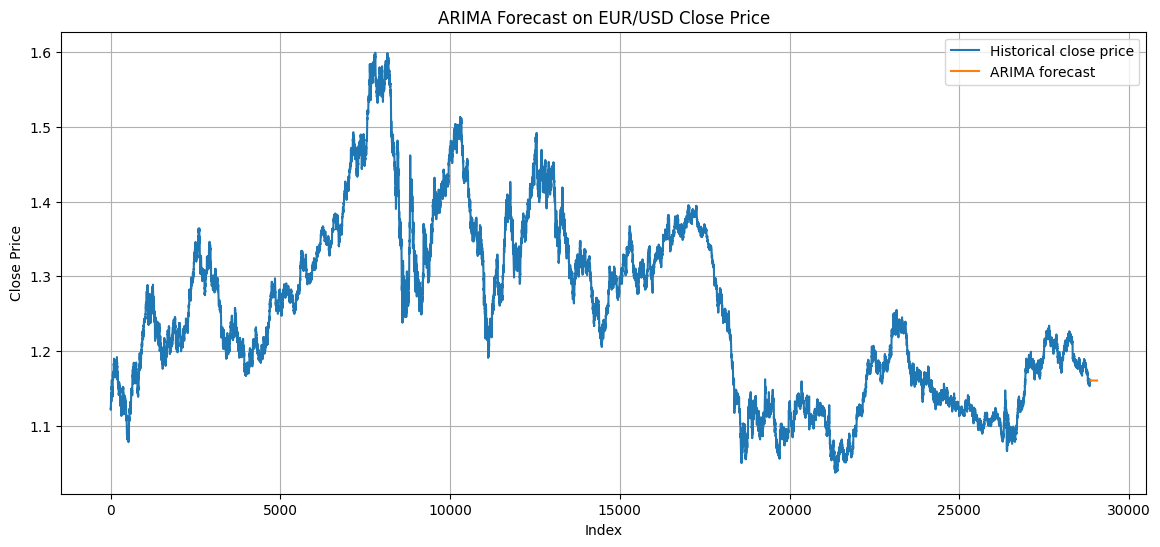

In [191]:
# visualisation
plt.figure(figsize=(14,6))
plt.plot(ts, label="Historical close price")
plt.plot(range(len(ts), len(ts)+n_steps), forecast, label="ARIMA forecast")
plt.title("ARIMA Forecast on EUR/USD Close Price")
plt.xlabel("Index")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

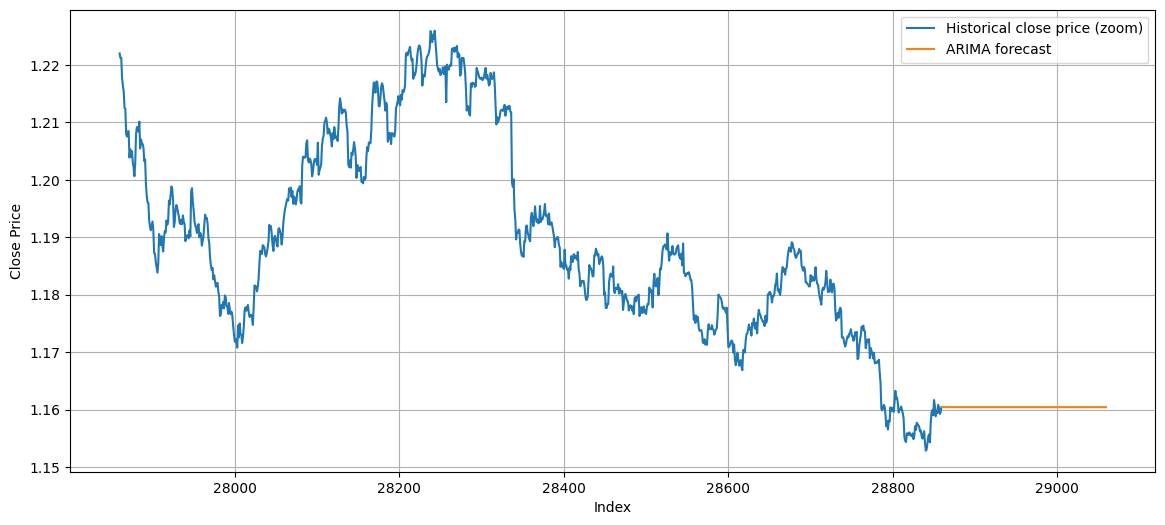

In [192]:
# zoom visualisation
plt.figure(figsize=(14,6))
plt.plot(ts[-1000:], label="Historical close price (zoom)")
plt.plot(range(len(ts), len(ts)+n_steps), forecast, label="ARIMA forecast")
plt.xlabel("Index")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

Now we do the ARIMA but with the GridSearch

In [194]:
# load data
df = pd.read_csv("Data_EURUSD_4h.csv")
df['Gmt time'] = pd.to_datetime(df['Gmt time'], format="%d.%m.%Y %H:%M:%S.%f")
df = df.sort_values("Gmt time").reset_index(drop=True)
ts = df["close"]

In [195]:
# Manual ARIMA with GridSearch
warnings.filterwarnings("ignore")
p = range(0, 4)
d = range(0, 1)
q = range(0, 4)

pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_order = None
best_model = None

print("Recherche du meilleur ARIMA...")

for order in pdq:
    model = ARIMA(ts, order=order)
    model_fit = model.fit()
    aic = model_fit.aic

    if aic < best_aic:
        best_aic = aic
        best_order = order
        best_model = model_fit

    print(f"ARIMA{order} - AIC: {aic:.2f}")
    
print("Meilleur modèle trouvé")
print(f"ARIMA{best_order} - AIC: {best_aic:.2f}")


Recherche du meilleur ARIMA...
ARIMA(0, 0, 0) - AIC: -40716.85
ARIMA(0, 0, 1) - AIC: -79672.43
ARIMA(0, 0, 2) - AIC: -113344.07
ARIMA(0, 0, 3) - AIC: -91396.59
ARIMA(1, 0, 0) - AIC: -253465.68
ARIMA(1, 0, 1) - AIC: -253464.06
ARIMA(1, 0, 2) - AIC: -253463.68
ARIMA(1, 0, 3) - AIC: -253471.34
ARIMA(2, 0, 0) - AIC: -253464.07
ARIMA(2, 0, 1) - AIC: -253462.70
ARIMA(2, 0, 2) - AIC: -253469.60
ARIMA(2, 0, 3) - AIC: -253471.60
ARIMA(3, 0, 0) - AIC: -253463.65
ARIMA(3, 0, 1) - AIC: -253464.55
ARIMA(3, 0, 2) - AIC: -253468.00
ARIMA(3, 0, 3) - AIC: -253469.59
Meilleur modèle trouvé
ARIMA(2, 0, 3) - AIC: -253471.60


In [196]:
# forecast with best model
n_steps = 200
forecast = best_model.forecast(steps=n_steps)

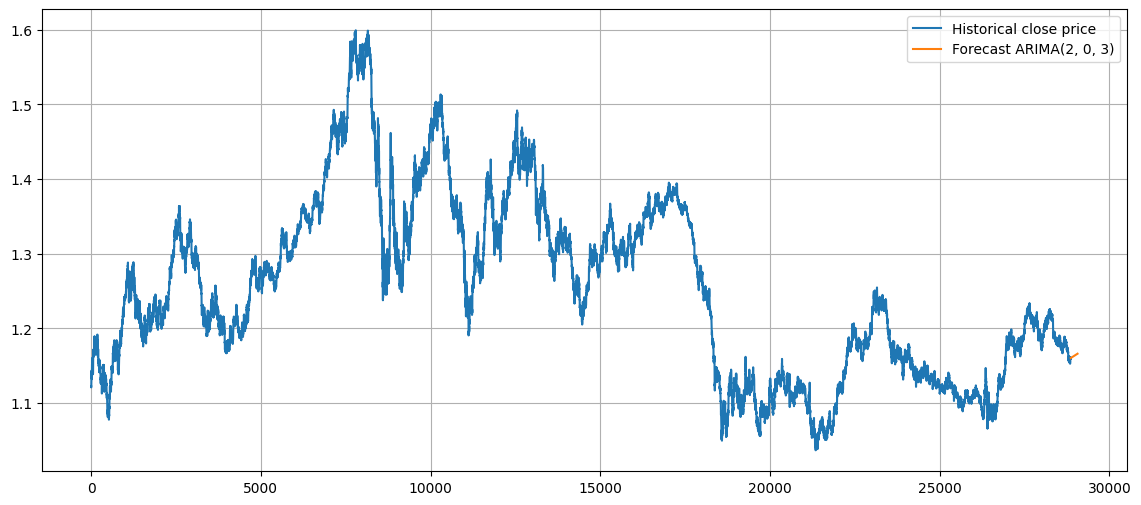

In [197]:
# visualisation 
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(ts, label="Historical close price")
plt.plot(range(len(ts), len(ts)+n_steps), forecast, label=f"Forecast ARIMA{best_order}")
plt.legend()
plt.grid(True)
plt.show()

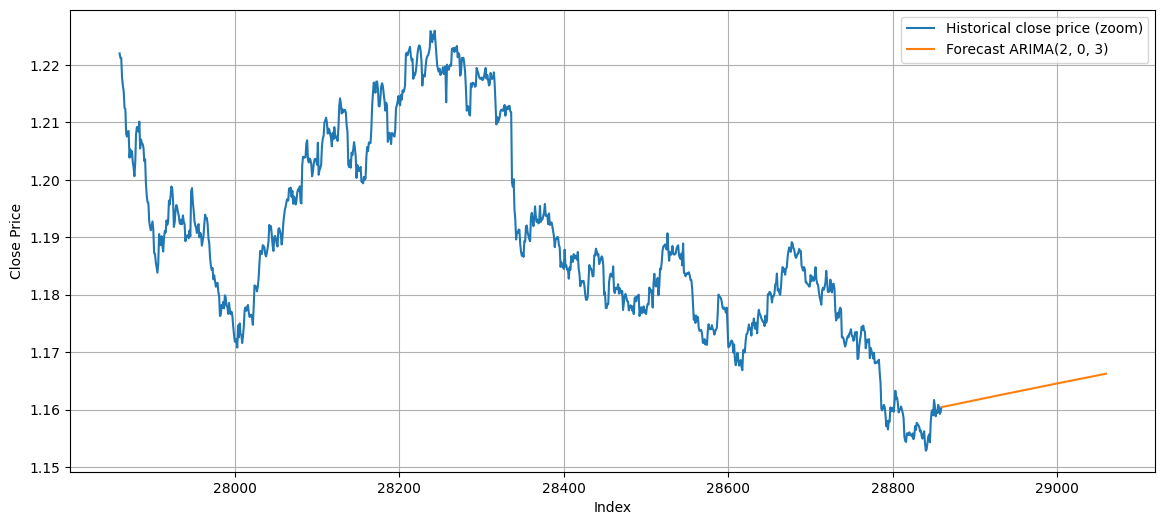

In [198]:
# zoom visualisation
plt.figure(figsize=(14,6))
plt.plot(ts[-1000:], label="Historical close price (zoom)")
plt.plot(range(len(ts), len(ts)+n_steps), forecast, label=f"Forecast ARIMA{best_order}")
plt.xlabel("Index")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()


In [199]:
# Evaluation ARIMA GridSearch
import numpy as np

split = int(len(ts) * 0.8)
train = ts[:split]
test  = ts[split:]

print("Train :", len(train), "points, Test :", len(test), "points")

Train : 23088 points, Test : 5772 points


In [200]:
from statsmodels.tsa.arima.model import ARIMA

order = best_order   

model = ARIMA(train, order=order)
model_fit = model.fit()

In [201]:
predictions = model_fit.forecast(steps=len(test))

In [202]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(test, predictions))
mae  = mean_absolute_error(test, predictions)
mape = np.mean(np.abs((test - predictions) / test)) * 100
r2   = r2_score(test, predictions)

print("Result ARIMA ")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"MAPE : {mape:.3f} %")
print(f"R²   : {r2:.3f}")


Result ARIMA 
RMSE : 0.118390
MAE  : 0.109842
MAPE : 9.655 %
R²   : -6.721


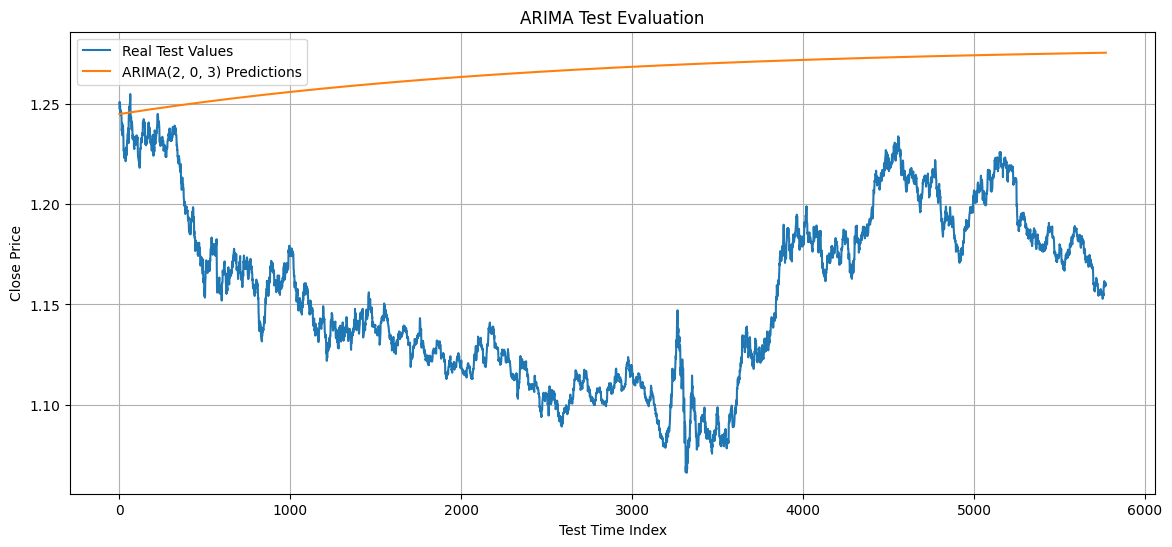

In [203]:
plt.figure(figsize=(14,6))
plt.plot(test.values, label="Real Test Values")
plt.plot(predictions.values, label=f"ARIMA{order} Predictions")
plt.title("ARIMA Test Evaluation")
plt.xlabel("Test Time Index")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()


The ARIMA model for EUR/USD does not allow us to track actual market variations because Forex prices behave mainly like a random walk. Therefore, ARIMA produces a smooth prediction curve, which approaches a divergent trend from the actual curve. This result is expected with volatile financial data. This shows that ARIMA models are not suitable for direct prediction of Forex prices.

Note: we used technical features (MA, volatility, etc.), but we could have used more variables to improve the prediction results, such as fundamental data such as GDP, interest rates, unemployment, etc. 
